In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [5]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    sr: float
    bpb: float
    boundary_percentage: float
    summary: str
    

In [19]:
def calculate_sr(state: BatsmanState):
    return {'sr' : (state['runs']/state['balls']) * 100}
    
def calculate_boundary_percentage(state: BatsmanState):
    return {'boundary_percentage' : ((state['fours'] * 4 + state['sixes'] * 6)/state['runs']) * 100}
    
def calculate_bpb(state: BatsmanState):
    return {'bpb' : state['balls']/(state['fours'] + state['sixes'])}

    
def summary(state: BatsmanState):
    summary = f"""
    Strike Rate: {state['sr']}
    Balls per Boundary: {state['bpb']}
    Boundary Percentage: {state['boundary_percentage']}
    """
    return {'summary' : summary} # this is called partial update
    

In [21]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_boundary_percentage',calculate_boundary_percentage)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('summary',summary)

# edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_boundary_percentage')
graph.add_edge(START, 'calculate_bpb')

graph.add_edge('calculate_sr', "summary")
graph.add_edge('calculate_boundary_percentage', 'summary')
graph.add_edge('calculate_bpb', 'summary')

graph.add_edge('summary', END)

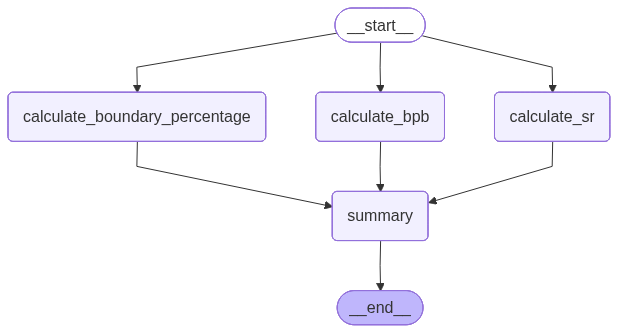

In [22]:
workflow = graph.compile()
workflow

In [23]:
initial_state = {"runs": 100, 'balls': 50, "fours": 6, "sixes": 4}
final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percentage': 48.0, 'summary': '\n    Strike Rate: 200.0\n    Balls per Boundary: 5.0\n    Boundary Percentage: 48.0\n    '}
